1. Importing the required libraries

In [1]:
# Step 1: Importing all the necessary libraries
from pathlib import Path

import pandas as pd                      # for data handling
import numpy as np                       # for numerical operations
import matplotlib.pyplot as plt          # for plotting graphs
import seaborn as sns                    # for visualization graphs
import joblib                            # for saving trained model artifacts

# Sklearn tools for ML tasks
from sklearn.model_selection import train_test_split   # to split data into train and test
from sklearn.preprocessing import StandardScaler       # to scale features
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report  # for evaluating model performance
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

# Resolve paths whether the notebook is run from the repository root or from notebooks/.
DATA_PATH = Path("../data/heart.csv")
if not DATA_PATH.exists():
    DATA_PATH = Path("data/heart.csv")

ARTIFACT_DIR = Path("../models")
if not DATA_PATH.exists():
    raise FileNotFoundError("Could not find heart.csv. Expected data/heart.csv or ../data/heart.csv")
if not ARTIFACT_DIR.parent.exists():
    ARTIFACT_DIR = Path("models")
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

Matplotlib is building the font cache; this may take a moment.


2. Loading the dataset

In [2]:
# Loaded the CSV dataset using pandas
df = pd.read_csv(DATA_PATH)

3. Understanding the data

In [3]:
# print the first 5 rows of the data set
print("First five rows:")
print(df.head())

First five rows:
   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   52    1   0       125   212    0        1      168      0      1.0      2   
1   53    1   0       140   203    1        0      155      1      3.1      0   
2   70    1   0       145   174    0        1      125      1      2.6      0   
3   61    1   0       148   203    0        1      161      0      0.0      2   
4   62    0   0       138   294    1        1      106      0      1.9      1   

   ca  thal  target  
0   2     3       0  
1   0     3       0  
2   0     3       0  
3   1     3       0  
4   3     2       0  


In [4]:
# print the last 5 rows of the data set
print("Last five rows:")
print(df.tail())

Last five rows:
      age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  \
1020   59    1   1       140   221    0        1      164      1      0.0   
1021   60    1   0       125   258    0        0      141      1      2.8   
1022   47    1   0       110   275    0        0      118      1      1.0   
1023   50    0   0       110   254    0        0      159      0      0.0   
1024   54    1   0       120   188    0        1      113      0      1.4   

      slope  ca  thal  target  
1020      2   0     2       1  
1021      1   1     3       0  
1022      1   1     2       0  
1023      2   0     2       1  
1024      1   1     3       0  


In [5]:
#number of rows and columns
df.shape

(1025, 14)

In [6]:
# Basic info of the data set
print("\nDataset Information:")
print(df.info())



Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB
None


4. Check for missing values

In [7]:
# Check for missing values
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


5. Exploratory Data Analysis (EDA)


In [8]:
# statistical measure about the data
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [9]:
#checking the distribution of target variable
df['target'].value_counts()

target
1    526
0    499
Name: count, dtype: int64

/var/folders/97/fppbfzns4m5fh265fg6jkshc0000gn/T/ipykernel_5688/363137004.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='target', data=df, palette='Set2')


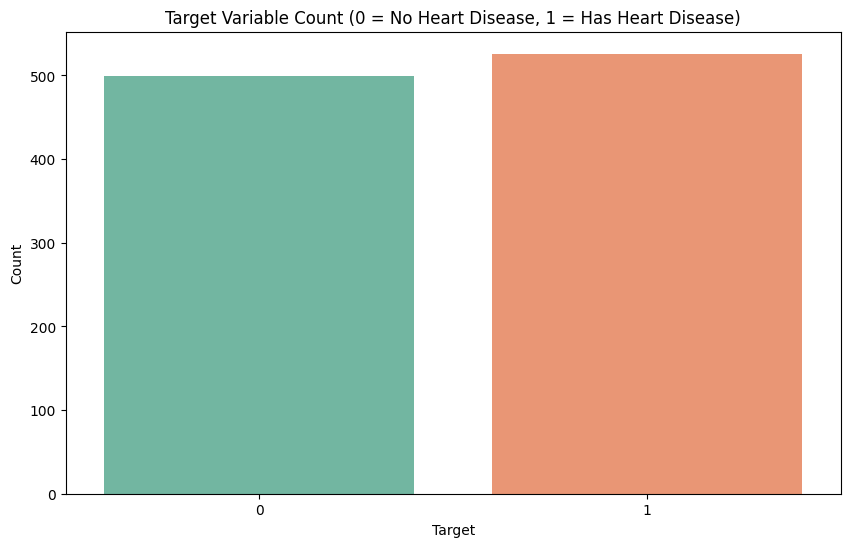

In [10]:
# Target column tells us whether heart disease is present or not (0 = No, 1 = Yes)
plt.figure(figsize=(10,6))
sns.countplot(x='target', data=df, palette='Set2')
plt.title("Target Variable Count (0 = No Heart Disease, 1 = Has Heart Disease)")
plt.xlabel("Target")
plt.ylabel("Count")
plt.show()


/var/folders/97/fppbfzns4m5fh265fg6jkshc0000gn/T/ipykernel_5688/3568314808.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='sex', data=df, palette='Set3')


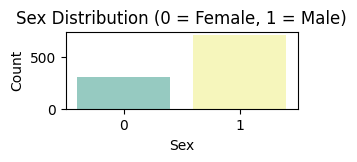

In [11]:
# sex distribution
plt.figure(figsize=(3,1))
sns.countplot(x='sex', data=df, palette='Set3')
plt.title("Sex Distribution (0 = Female, 1 = Male)")
plt.xlabel("Sex")
plt.ylabel("Count")
plt.show()


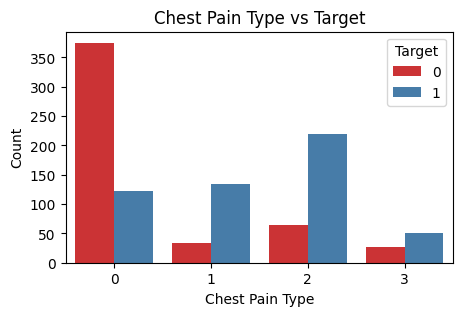

In [12]:
#chest pain vs target
plt.figure(figsize=(5,3))
sns.countplot(x='cp', hue='target', data=df, palette='Set1')
plt.title("Chest Pain Type vs Target")
plt.xlabel("Chest Pain Type")
plt.ylabel("Count")
plt.legend(title="Target")
plt.show()


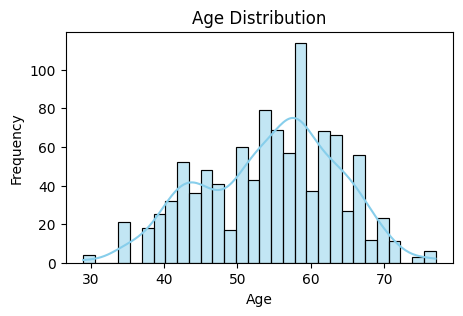

In [13]:
#age distribution
plt.figure(figsize=(5,3))
sns.histplot(df['age'], kde=True, bins=30, color='skyblue')
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()


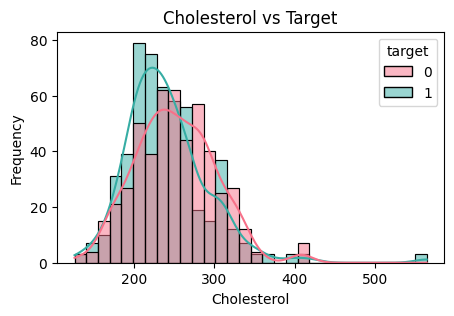

In [14]:
#cholesterol vs target
plt.figure(figsize=(5,3))
sns.histplot(data=df, x='chol', hue='target', bins=30, kde=True, palette='husl')
plt.title("Cholesterol vs Target")
plt.xlabel("Cholesterol")
plt.ylabel("Frequency")
plt.show()


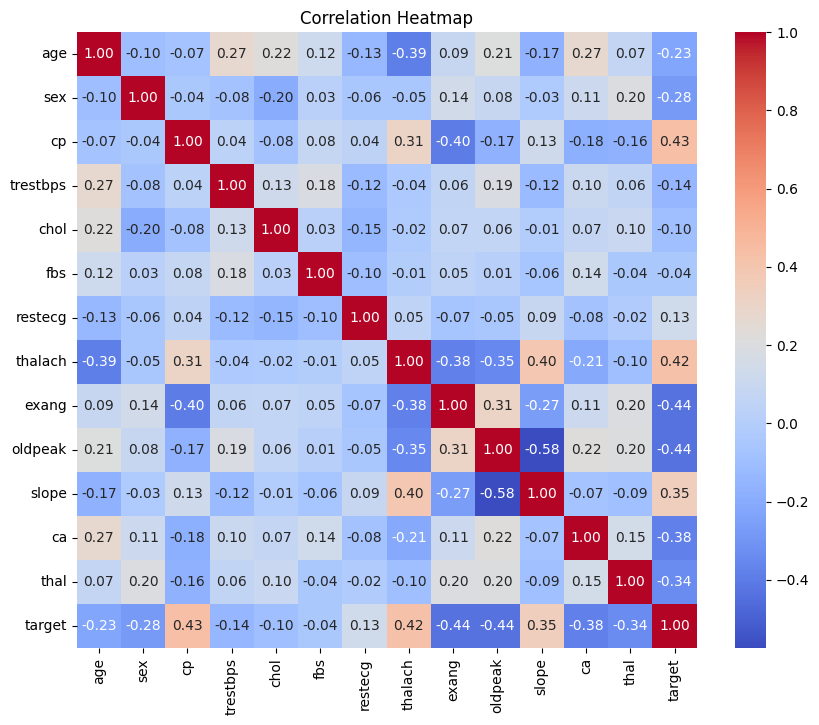

In [15]:
#correlation heatmap
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Heatmap")
plt.show()


6. Data preparation

In [16]:
#Splitting features and target
X = df.drop('target', axis=1)  # Features (inputs)
Y = df['target']               # Target (output)


In [17]:
#Train-Test Split
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, stratify=Y, random_state=42)


In [18]:
from sklearn.preprocessing import StandardScaler
#Scaling the features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


7. Defining and training multiple models

In [19]:
# Define the models we want to test
models = {
    "Logistic Regression": LogisticRegression(),
    "K-Nearest Neighbors": KNeighborsClassifier(),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "Support Vector Machine": SVC(probability=True)
}


8. Model evaluation loop


📌 Logistic Regression Accuracy: 80.98%
Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.70      0.78       100
           1       0.76      0.91      0.83       105

    accuracy                           0.81       205
   macro avg       0.82      0.81      0.81       205
weighted avg       0.82      0.81      0.81       205



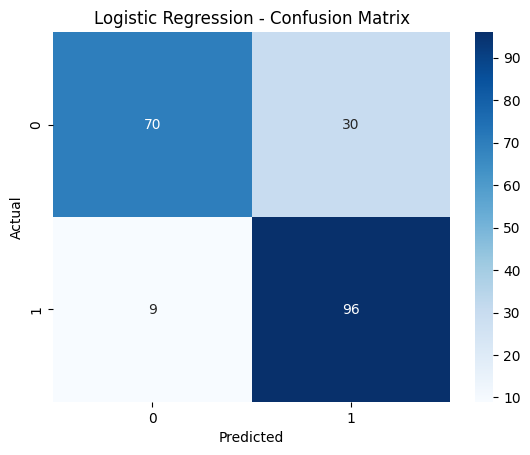


📌 K-Nearest Neighbors Accuracy: 86.34%
Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.87      0.86       100
           1       0.87      0.86      0.87       105

    accuracy                           0.86       205
   macro avg       0.86      0.86      0.86       205
weighted avg       0.86      0.86      0.86       205



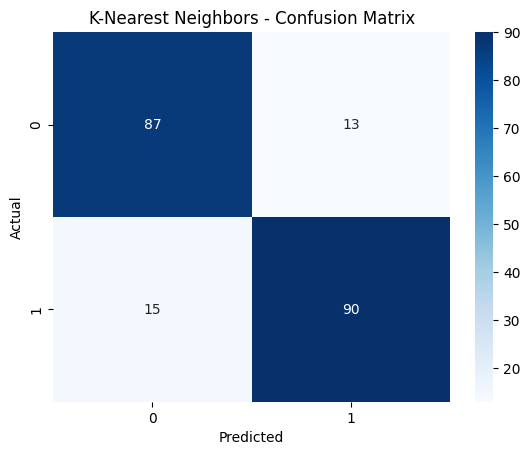


📌 Decision Tree Accuracy: 98.54%
Classification Report:
              precision    recall  f1-score   support

           0       0.97      1.00      0.99       100
           1       1.00      0.97      0.99       105

    accuracy                           0.99       205
   macro avg       0.99      0.99      0.99       205
weighted avg       0.99      0.99      0.99       205



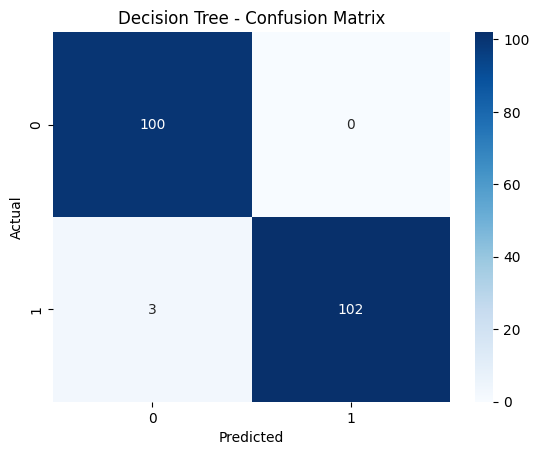


📌 Random Forest Accuracy: 100.00%
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       100
           1       1.00      1.00      1.00       105

    accuracy                           1.00       205
   macro avg       1.00      1.00      1.00       205
weighted avg       1.00      1.00      1.00       205



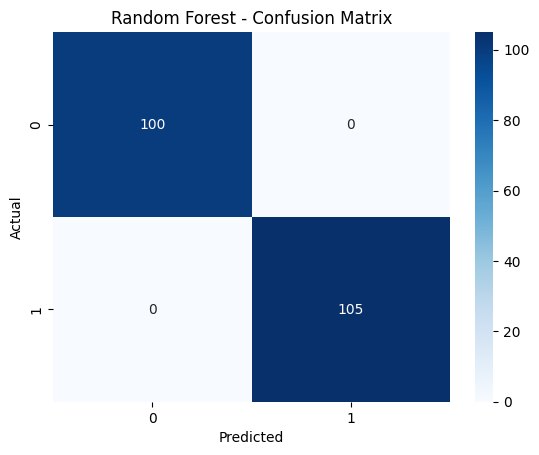


📌 Support Vector Machine Accuracy: 92.68%
Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.91      0.92       100
           1       0.92      0.94      0.93       105

    accuracy                           0.93       205
   macro avg       0.93      0.93      0.93       205
weighted avg       0.93      0.93      0.93       205



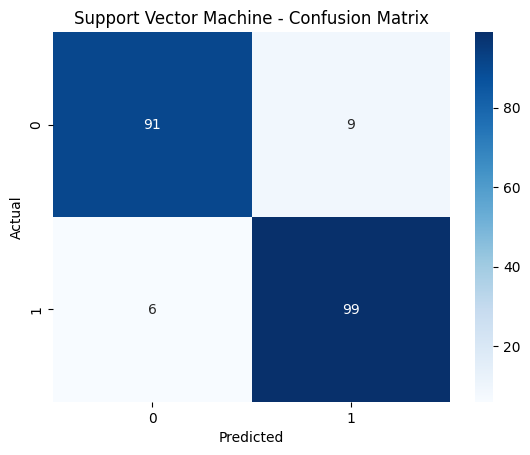

In [20]:
accuracies = {}

for name, model in models.items():
    model.fit(X_train, Y_train)                     # Train model
    Y_pred = model.predict(X_test)                  # Predict on test set
    acc = accuracy_score(Y_test, Y_pred)            # Calculate accuracy
    accuracies[name] = acc                          # Store accuracy
    print(f"\n📌 {name} Accuracy: {acc*100:.2f}%")
    print("Classification Report:")
    print(classification_report(Y_test, Y_pred))    # Detailed performance

    # Show confusion matrix
    cm = confusion_matrix(Y_test, Y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f"{name} - Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

9. Comparing Model accuracy

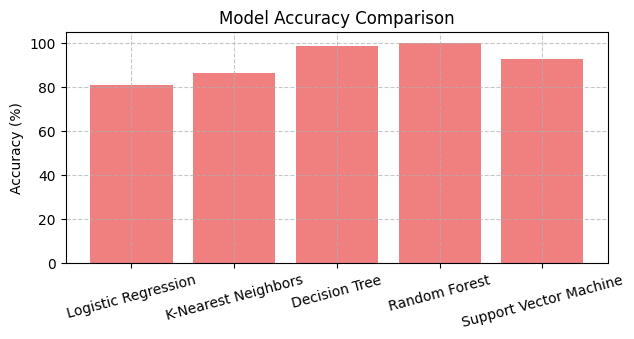

In [21]:
plt.figure(figsize=(7,3))
plt.bar(accuracies.keys(), [v*100 for v in accuracies.values()], color='lightcoral')
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy (%)")
plt.xticks(rotation=15)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()


10. Final prediction with the best model

In [22]:
# Picking the model with highest accuracy
best_model_name = max(accuracies, key=accuracies.get)
best_model = models[best_model_name]
print(f"\n🏆 Best model: {best_model_name} with accuracy: {accuracies[best_model_name]*100:.2f}%")



🏆 Best model: Random Forest with accuracy: 100.00%


In [23]:
# Train and save the final model artifacts
X = df.drop("target", axis=1)
y = df["target"]

final_scaler = StandardScaler()
X_scaled = final_scaler.fit_transform(X)

final_model = RandomForestClassifier(random_state=42)
final_model.fit(X_scaled, y)

joblib.dump(final_model, ARTIFACT_DIR / "best_model.pkl")
joblib.dump(final_scaler, ARTIFACT_DIR / "scaler.pkl")

print(f"Saved model artifacts to: {ARTIFACT_DIR.resolve()}")

Saved model artifacts to: /Users/ayeshanaaz/Documents/New project/heart-disease-prediction/models


In [24]:
# Example input data for prediction
# Format must be: [age, sex, cp, trestbps, chol, fbs, restecg, thalach, exang, oldpeak, slope, ca, thal]
input_data = np.array([[70, 1, 0, 145, 174, 0, 1, 125, 1, 2.6, 0, 0, 3]])

if input_data.shape[1] != X.shape[1]:
    print("Error in data. Please check your input.")
else:
    input_scaled = final_scaler.transform(input_data)
    prediction = final_model.predict(input_scaled)

    print("Prediction for the given input:")
    if prediction[0] == 1:
        print("High chance. Please consult a doctor.")
    else:
        print("Low risk. Stay healthy!")

Prediction for the given input:
Low risk. Stay healthy!


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [25]:
def predict_heart_disease(input_list):
    """
    Predicts heart disease risk based on input data.
    input_list must contain 13 features in this exact order:
    [age, sex, cp, trestbps, chol, fbs, restecg, thalach,
     exang, oldpeak, slope, ca, thal]
    """
    if len(input_list) != 13:
        raise ValueError("Input must contain exactly 13 features.")

    input_data = np.array([input_list])
    input_scaled = final_scaler.transform(input_data)
    prediction = final_model.predict(input_scaled)[0]
    probability = final_model.predict_proba(input_scaled)[0][1]

    risk_label = "High chance of heart disease" if prediction == 1 else "Low risk of heart disease"
    return {"prediction": int(prediction), "heart_disease_probability": probability, "risk_label": risk_label}

sample_patient = [70, 1, 0, 145, 174, 0, 1, 125, 1, 2.6, 0, 0, 3]
predict_heart_disease(sample_patient)

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


{'prediction': 0,
 'heart_disease_probability': np.float64(0.0),
 'risk_label': 'Low risk of heart disease'}